# Parcel Advection
<br>

**Author:** Jack Logan

This notebook uses the class `LagrangianTracking` from `blue_ice_tools` to select known crevasses and track those parcels through time.
There are two examples of picking known points, one with three parcels along the same crevasses, and a second with five parcels across several crevasses.
The final example uses an ensemble of 800 randomly selected parcels to assess large scale trends.

This code generates Figures 4-9 for the publication.

### Import Packages

In [1]:
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import blue_ice_tools as bit

import cmocean.cm as ccm     # Colormaps
import matplotlib.cm as mcm  # Colormaps
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import signal
from scipy.ndimage import binary_erosion
from shapely.ops import polygonize
from time import time

# Matplotlib font params
plt.rcParams.update({
    "mathtext.fontset": "dejavuserif",
    "font.family": "serif",
    "font.size":14,
})

### Helper Functions

In [2]:
def first_fracture(parc, thresh=0.6):
    """Return the first fracture of a single parcel."""
    try:
        return parc.where(parc.fracture_conf > thresh, drop=True).isel(t=0)
    except:
        return None

def parcel_lineplot(ax, parcels, var, cmap, align='date', style='parcel', thresh=0.6):
    """
    Plot per-parcel lineplots with fracture markers.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    parcels : xr.Dataset
    var : str
        Variable to plot on the y-axis.
    cmap : matplotlib colormap
    align : 'date' or 'fracture'
        If 'date', x-axis is mid_date.
        If 'fracture', x-axis is days relative to first fracture date.
        Parcels with no fracture date are skipped when align='fracture'.
    style : 'parcel' or 'ensemble'
        If 'parcel', each line is colored by parcel ID via cmap.
        If 'ensemble', all lines are grey and translucent; fracture
        markers are suppressed.
    thresh : float
        Fracture confidence threshold. Default 0.6.
    """
    norm = Normalize(vmin=parcels['parcel'].min(), vmax=parcels['parcel'].max())

    for parcel_id, group in parcels.groupby('parcel'):
        first_frac = first_fracture(group, thresh=thresh)

        # Skip unbroken parcels in fracture-aligned mode
        if align == 'fracture' and first_frac is None:
            continue

        # Build x axis
        if align == 'fracture':
            x = (group['mid_date'] - first_frac['mid_date']) / np.timedelta64(1, 'D')
            x_frac = 0
        else:
            x = group['mid_date']
            x_frac = first_frac['mid_date'] if first_frac is not None else None

        # Style
        if style == 'ensemble':
            color, alpha, lw = 'grey', 0.25, 0.75
        else:
            color, alpha, lw = cmap(norm(parcel_id)), 1.0, 1.5

        line, = ax.plot(
            x, group[var].squeeze(),
            color=color, alpha=alpha, linewidth=lw,
            zorder=parcel_id
        )

        if style == 'parcel' and x_frac is not None:
            ax.scatter(x_frac, first_frac[var], color=color, s=125, marker='s', zorder=parcel_id)

    amax = float(np.abs(parcels[var]).max())
    ax.set_ylim(-(amax * 1.05), amax * 1.05)
    return line

def plot_fracture_location(ax, parcels, cmap):
    norm = Normalize(vmin=parcels['parcel'].min(), vmax=parcels['parcel'].max())
    # Add line connections per parcel
    for parcel_id, group in parcels.groupby('parcel'):
        color = cmap(norm(parcel_id))

        # . . Get first fracture date
        first_frac = first_fracture(group)
    
        # Plot stress at that date
        if first_frac is not None:
            ax.scatter(
                first_frac['x'], first_frac['y'],
                color=color,
                s=125,
                marker='s'
            )

## Load Data

Here we load the shapefiles, velocity dataset, and cropped fracture dataset.
We compute the surface stresses using `blue_ice_tools`.

In [3]:
# . . Shirase Blue ice outline
shirase_shape = gpd.read_file('../data/shapefiles/shirase.shp')
grounding_line = gpd.read_file('../data/shapefiles/RINGS_grounded_2022_polyline.shp')

# . . Get velocity data for shirase, calculate stresses
vel = xr.open_dataset('../data/velocity/velocity-timeseries.nc', decode_coords='all')
stress = bit.calc_strain_stress(vel, window_length=25, dx=50, dy=50)

# . . Load in fracture data, merge w/ stress
frac = xr.open_dataset('../data/shirase-fracture.nc', decode_coords='all')

## Initalize Lagrangian Tracker

The `LagrangianTracking` class tracks ice parcels in a **Lagrangian reference frame** &ndash; we follow fixed parcels of ice as they advect through the domain, rather than observing a fixed geographic location through time (Eulerian).

**Initialization** takes the stress dataset (`ds`, containing `vx` and `vy`) and an optional auxiliary dataset (`extra_ds`, here the fracture confidence grids). 
On construction, the class builds two `RegularGridInterpolator` objects &ndash; one for each velocity component &ndash; over the `(time, y, x)` grid using nearest-neighbour lookup. 
Time is internally converted to days since the start of the record for numerical stability.

**Advection** is performed using a 4th-order Runge-Kutta (RK4) scheme, which evaluates velocity at four intermediate points per timestep for higher accuracy than a simple Euler step. 
Velocities are converted from m yr$^{-1}$ to m day$^{-1}$ during integration. The loop halts early if the parcel exits the valid domain (i.e., a NaN velocity is returned).

**`parcel_advection(x0, y0, t0)`** is the entry point for named parcels. 
Given one or more starting coordinates and a start date, it runs RK4 both **forward and backward** from `t0`, then concatenates the two legs into a single trajectory spanning the full record. 
At each position, variables from the stress dataset &ndash; and the fracture dataset if provided (sampled with backfill) &ndash; are co-located via nearest-neighbour lookup, producing a parcel-indexed timeseries `xr.Dataset`.

**`ensemble_advection(clip_shapes, mask_date, N, seed)`** randomly seeds `N` parcels across the ice shelf and advects them all. 
It works in three steps: 
1. sequentially clips `extra_ds` (or `ds`) using the provided geometries to define the valid sampling region &ndash; here, inside the Shirase catchment and outside the grounding line
2. erodes the boundary inward by `erode_iters` pixels to avoid selecting edge parcels
3. randomly samples `N` start points from the remaining valid pixels using the provided `seed` for reproducibility.

All parcels are then advected via `parcel_advection` and the result is median-filtered along the time axis before returning.

In [4]:
frac_thresh = 0.6  # Initialize fracture threshold early
tracker = bit.LagrangianTracking(stress, extra_ds=frac)

## Pick parcels to track

For our first example, we'll pick 3 parcels at different locations along the same crevasse.

In [5]:
# . . Pick 3 parcels from a single crevasse
x0 = np.array([  # x-coordinates 
    1.3662e6,
    1.3667e6,
    1.3669e6,
])
y0 = np.array([  # y-coordinates
    1.71745e6,
    1.7170e6, 
    1.7156e6,
])
t0 = np.array(['2022-03-25']*len(x0))

# . . Advect Parcels
parcels_raw = tracker.parcel_advection(x0, y0, t0)
parcels_singlecrev = bit.apply_med_filt(parcels_raw, size=(1, 10))  # Filter along time dimension

parcels_singlecrev.to_netcdf('../data/trajectories/ex1-singlecrev-parcels.nc')

### Figure 4: Mapping picked parcels

Show the parcels on the fracture confidence map.

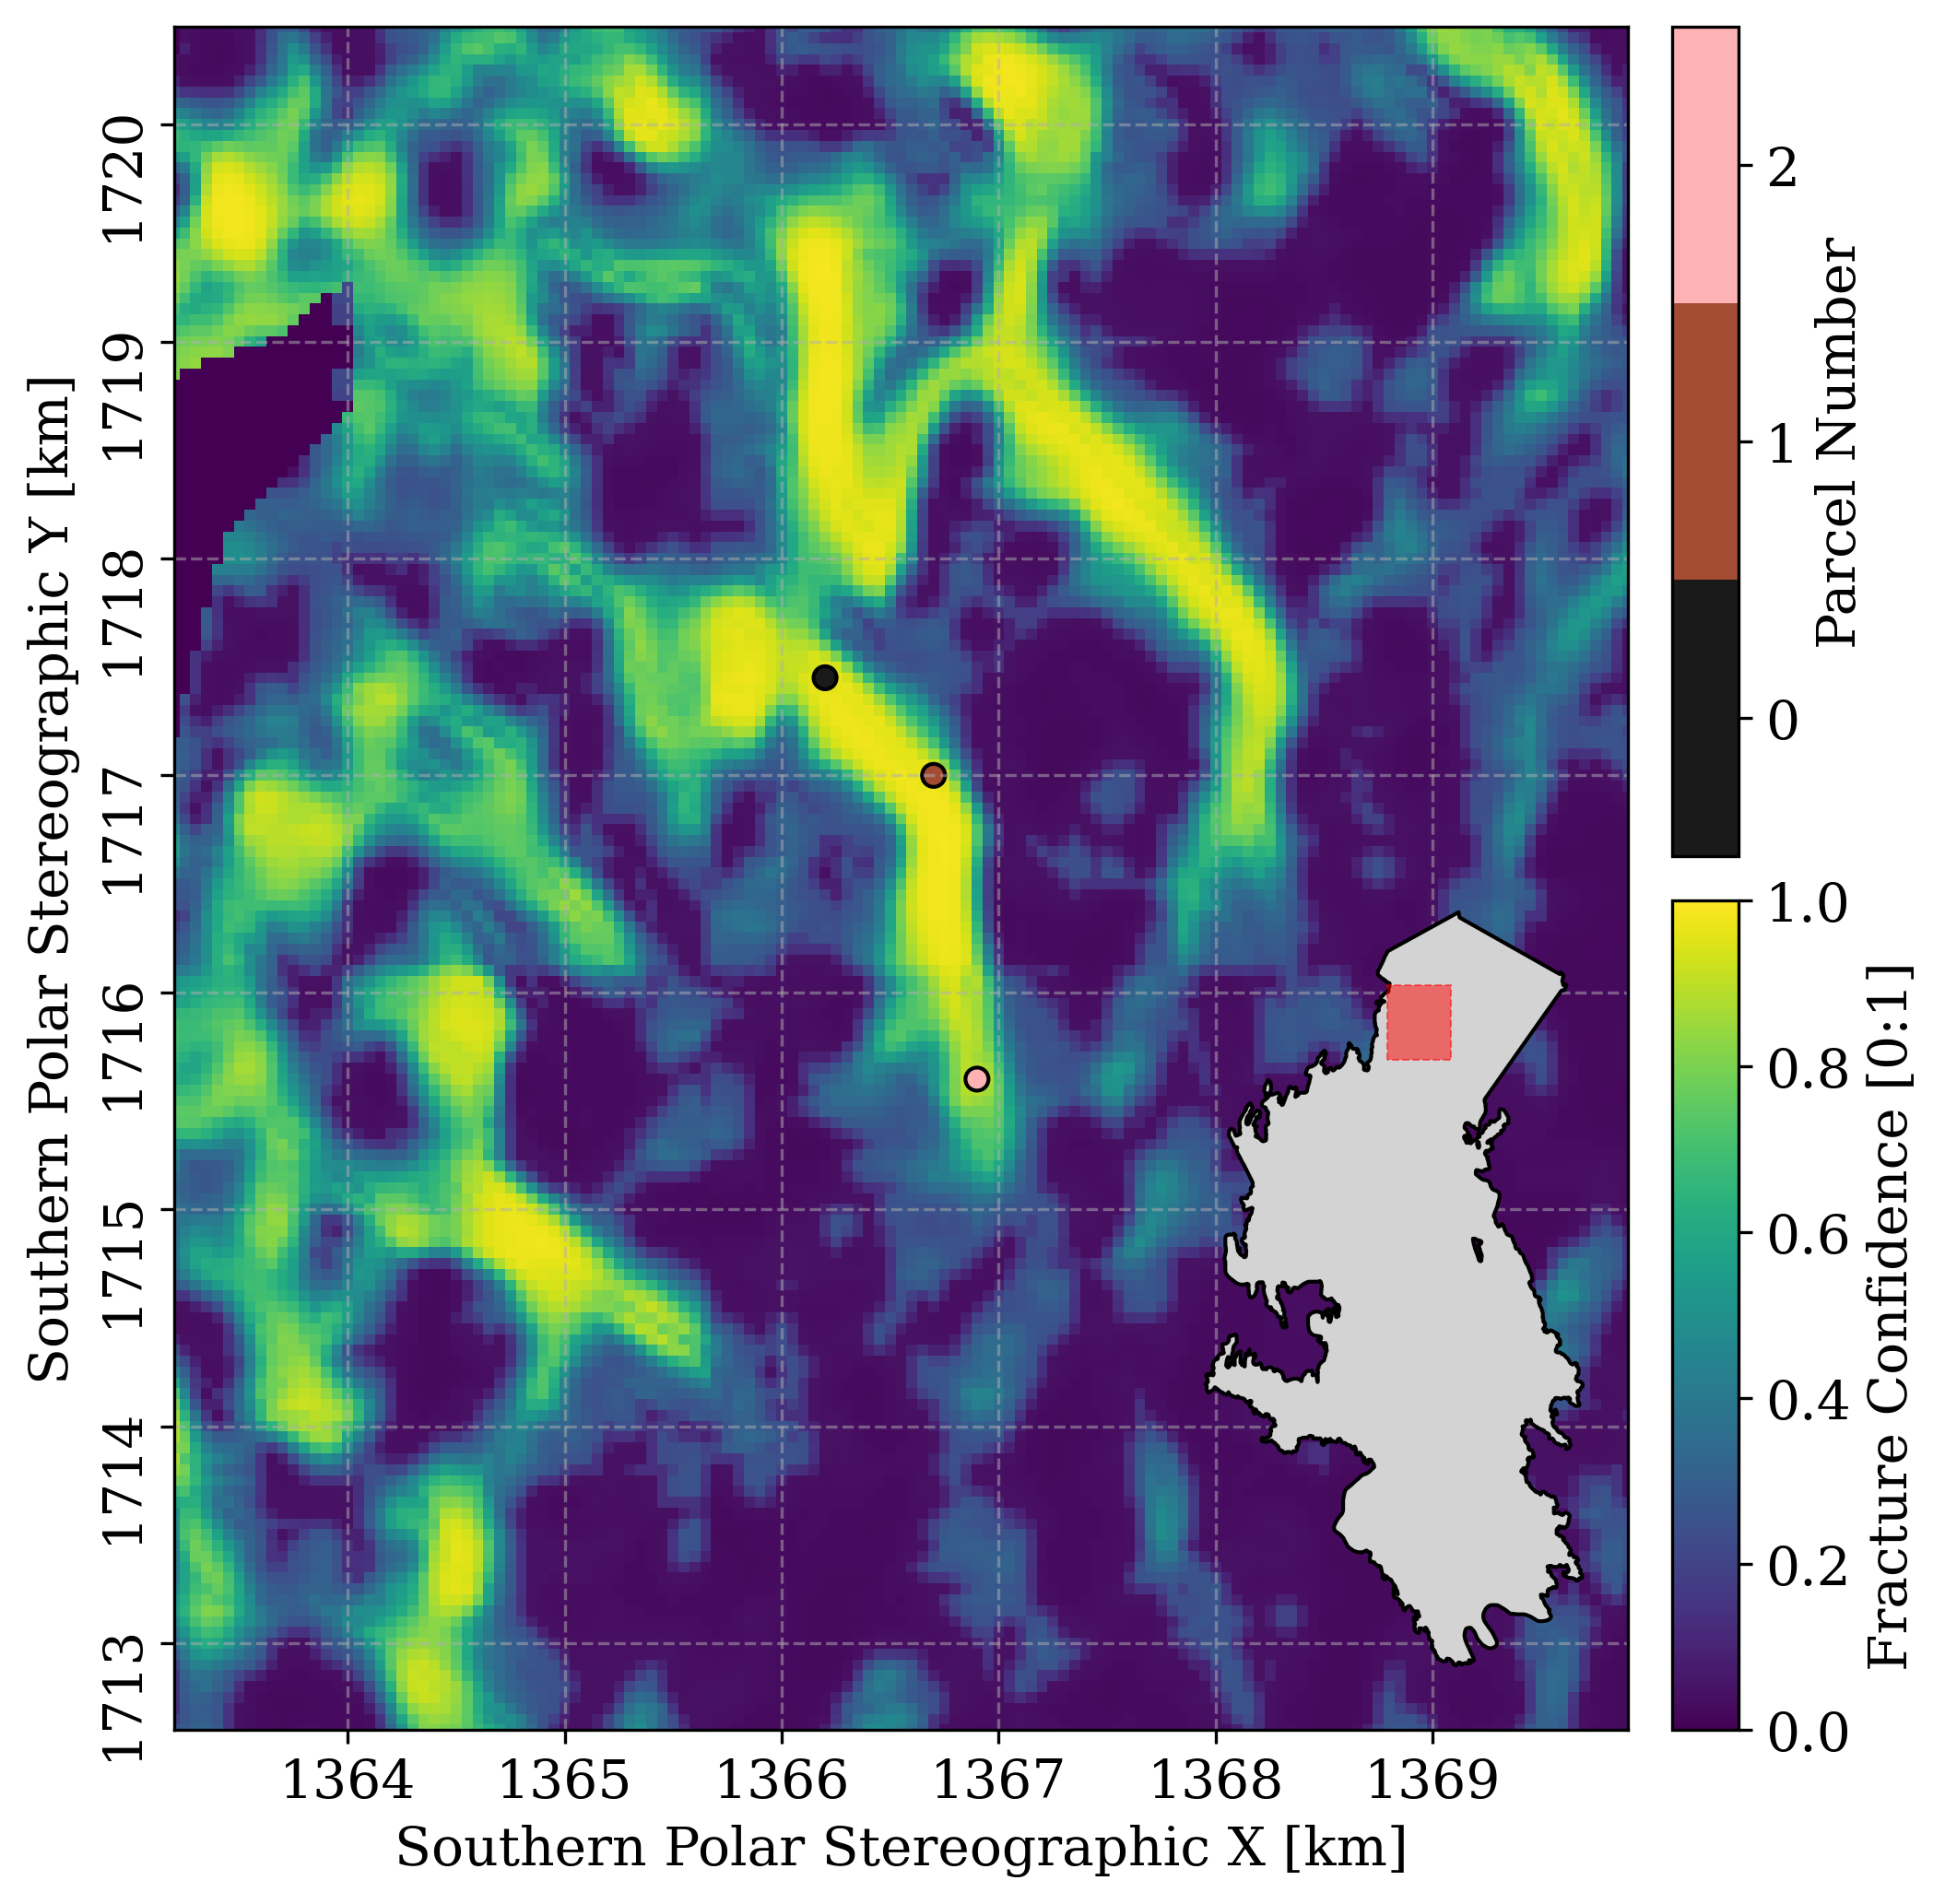

In [6]:
# . . Normalize parcels for plotting
n_parcels = len(parcels_singlecrev.parcel)
levels = [i-0.5 for i in range(n_parcels+1)]
cmap = ccm.amp_i

fig, ax = plt.subplots(figsize=(8,8), dpi=300)

qm = frac['fracture_conf'].sel(mid_date='2022-03-25', method='bfill').plot(
    ax=ax, vmin=0, vmax=1, add_colorbar=False
)

cs = parcels_singlecrev.sel(mid_date='2022-03-25').plot.scatter(
    x='x', y='y', hue='parcel',
    ax=ax, cmap=ccm.amp_i,
    levels=levels,
    add_colorbar=False,
    ec='k'
)

xmin, xmax = x0.min()-3000, x0.max()+3000
ymin, ymax = y0.min()-3000, y0.max()+3000
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
bit.format_map(ax)

pos = ax.get_position()

# Compute new position spanning ax1 to ax2
px1 = pos.x1
py0 = pos.y0
py1 = pos.y1
width = 0.03
wspace = 0.02
height = (py1 - py0) / 2 - 0.01

cax1 = fig.add_axes([
    px1+wspace,
    py0,
    width,
    height
])

cax2 = fig.add_axes([
    px1+wspace,
    py1-height,
    width,
    height
])

cbar1 = fig.colorbar(
    qm, cax=cax1,
    label='Fracture Confidence [0:1]'
)
cbar2 = fig.colorbar(
    cs, cax=cax2, 
    label='Parcel Number', ticks=[i for i in range(n_parcels)]
)
cbar2.ax.yaxis.minorticks_off()

# . . Create an inset map for context
width = 1.5
aspect = 2
iax = inset_axes(ax, loc="lower right", height=2*width, width=width, borderpad=.5)

shirase_shape.plot(ax=iax, ec='k', fc='lightgray')
iax.fill(
    [xmin, xmin, xmax, xmax],
    [ymin, ymax, ymax, ymin],
    ec='r',
    fc='r',
    alpha=0.5,
    lw=0.5,
    ls='--'
)
iax.set_axis_off()

fig.savefig('../media/f04-ex1-parcel-selection.png', bbox_inches='tight')
plt.show()

### Figure 5: Plot Parcels Trajectory, Principal Stresses

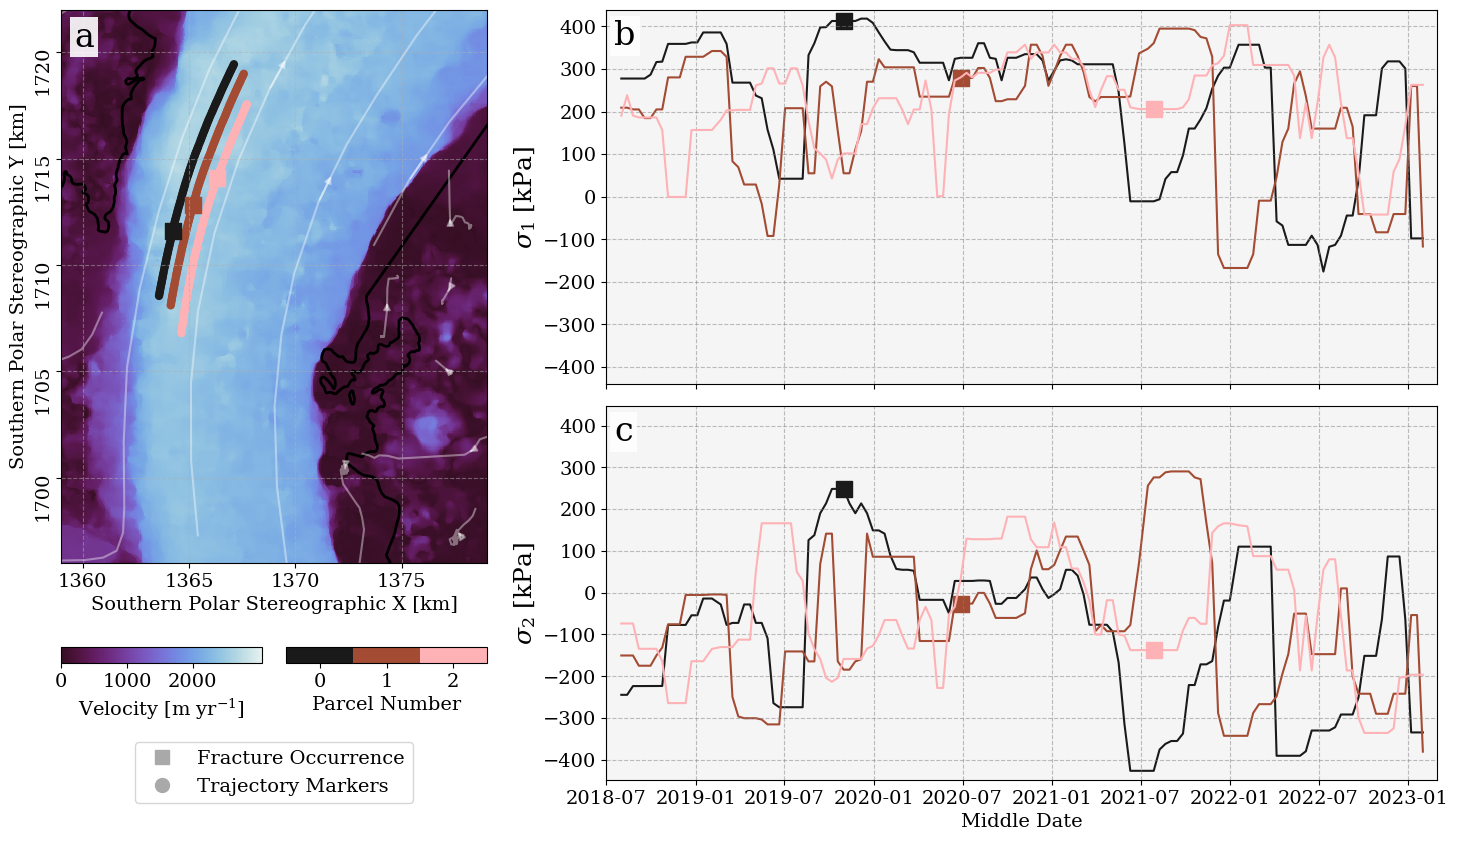

In [7]:
def plot_parcel_stresses(parcels, stress, shape, cmap, savepath):
    # . . Parcel Scatterplot levels
    n_parcels = len(parcels.parcel)
    levels = [i-0.5 for i in range(n_parcels+1)]
        
    fig = plt.figure(figsize=(20,10))
    
    # Use gridspec to make irregular grid
    gs = GridSpec(6, 3, height_ratios=(1, .1, 1, 1, .1, 1), width_ratios=(0.5, 0.5, 1))
    ax1 = fig.add_subplot(gs[0:4, :2])  # Map subplot
    ax2 = fig.add_subplot(gs[0:3, 2:])  # P1 subplot
    ax3 = fig.add_subplot(gs[3:,  2:])  # P2 subplot
    
    cax1 = fig.add_subplot(gs[4, 0])  # Colorbar axis (vel)
    cax2 = fig.add_subplot(gs[4, 1])  # Colorbar axis (parcel)
    
    legax = fig.add_subplot(gs[5, :2])  # Legend axis
    
    # . . Plot parcels geospatially
    qm = stress['vv'].sel(mid_date='2022-03-25').plot(
        ax=ax1,
        cmap=ccm.dense_r,
        add_colorbar=False
    )
    
    stress.sel(mid_date='2022-03-25').plot.streamplot(
        x='x',  y='y',
        u='vx', v='vy',
        ax=ax1, color=(1, 1, 1, .4),
    )
        
    # Parcel trajectories
    cs = parcels.plot.scatter(
        x='x', y='y', hue='parcel', 
        cmap=cmap, 
        ax=ax1, 
        ec='none',
        levels=levels,
        add_colorbar=False
    )
    
    # Shapefile bounding area
    shape.plot(ax=ax1, fc='none', ec='k', lw=2)
    
    plot_fracture_location(ax1, parcels, cmap)
    
    # Prettify the plot
    ax1.set_xlim(1.359e6, 1.379e6)
    ax1.set_ylim(1.696e6, 1.722e6)
    bit.format_map(ax1)

    xmin, xmax = np.array(['2018-07-01', '2023-02-28'], 'datetime64')
    # . . Plot timeseries of P1 by parcel
    parcel_lineplot(ax2, parcels, 'sigma1', cmap)
    ax2.set_ylabel('$\\sigma_1$ [kPa]', fontsize=18)
    ax2.set_xlabel(None)
    ax2.set_xlim(xmin, xmax)
    ax2.set_xticklabels([])
    ax2.set_title(None)
    ax2.grid(ls='--', c='grey', alpha=0.5)
    ax2.set_facecolor('whitesmoke')
    
    # . . Plot timseries of P2 by parcel
    parcel_lineplot(ax3, parcels, 'sigma2', cmap)
    ax3.set_xlabel('Middle Date')
    ax3.set_ylabel('$\\sigma_2$ [kPa]', fontsize=18)
    ax3.set_title(None)
    ax3.set_xlim(xmin, xmax)
    ax3.grid(ls='--', c='grey', alpha=0.5)
    ax3.set_facecolor('whitesmoke')
    
    # . . Add colorbars
    cbar1 = fig.colorbar(
        qm, cax=cax1, orientation='horizontal',
        label='Velocity [m yr$^{-1}$]', ticks=[0, 1000, 2000]
    )
    cbar2 = fig.colorbar(
        cs, cax=cax2, orientation='horizontal', 
        label='Parcel Number', ticks=[i for i in range(n_parcels)]
    )
    
    fig.subplots_adjust(wspace=-0.1)
    
    # get axes postions for map, both colorbars
    pos1 = ax1.get_position()
    cpos1 = cbar1.ax.get_position()
    cpos2 = cbar2.ax.get_position()
    
    gap = 0.02
    cbar1.ax.set_position([pos1.x0,      pos1.y0-0.1, cpos1.x1-pos1.x0-gap, cpos1.height])
    cbar2.ax.set_position([cpos2.x0+gap, pos1.y0-0.1, pos1.x1-cpos2.x0-gap, cpos2.height])
    cbar2.ax.xaxis.minorticks_off()
    
    # . . Fracture marker dummy artist
    handles = [
        Line2D(
            [], [], 
            color='darkgrey', marker='s', linestyle='None',
            markersize=10, label='Fracture Occurrence'
        ),
        Line2D(
            [], [],
            color='darkgrey', marker='o', linestyle='None',
            markersize=10, label='Trajectory Markers '
        )
    ]
    
    # Add it to one of your timeseries axes, e.g. ax2 or ax3
    legax.set_axis_off()
    legax.legend(
        handles=handles,
        loc='lower center',
        frameon=True,
        bbox_to_anchor=(0.5, -0.06)
    )
    lpos = legax.get_position()
    legax.set_position([pos1.x0, lpos.y0, pos1.width, pos1.height])
    
    bit.map_patch(ax1,  'a', fs=24)
    bit.plot_patch(ax2, 'b', fs=24)
    bit.plot_patch(ax3, 'c', fs=24)
    
    fig.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()

plot_parcel_stresses(parcels_singlecrev, stress, shirase_shape, ccm.amp_i, '../media/f05-ex1-map-principal-stresses.png')
plt.close()

### Figure 6: Timeseries of parcel properties

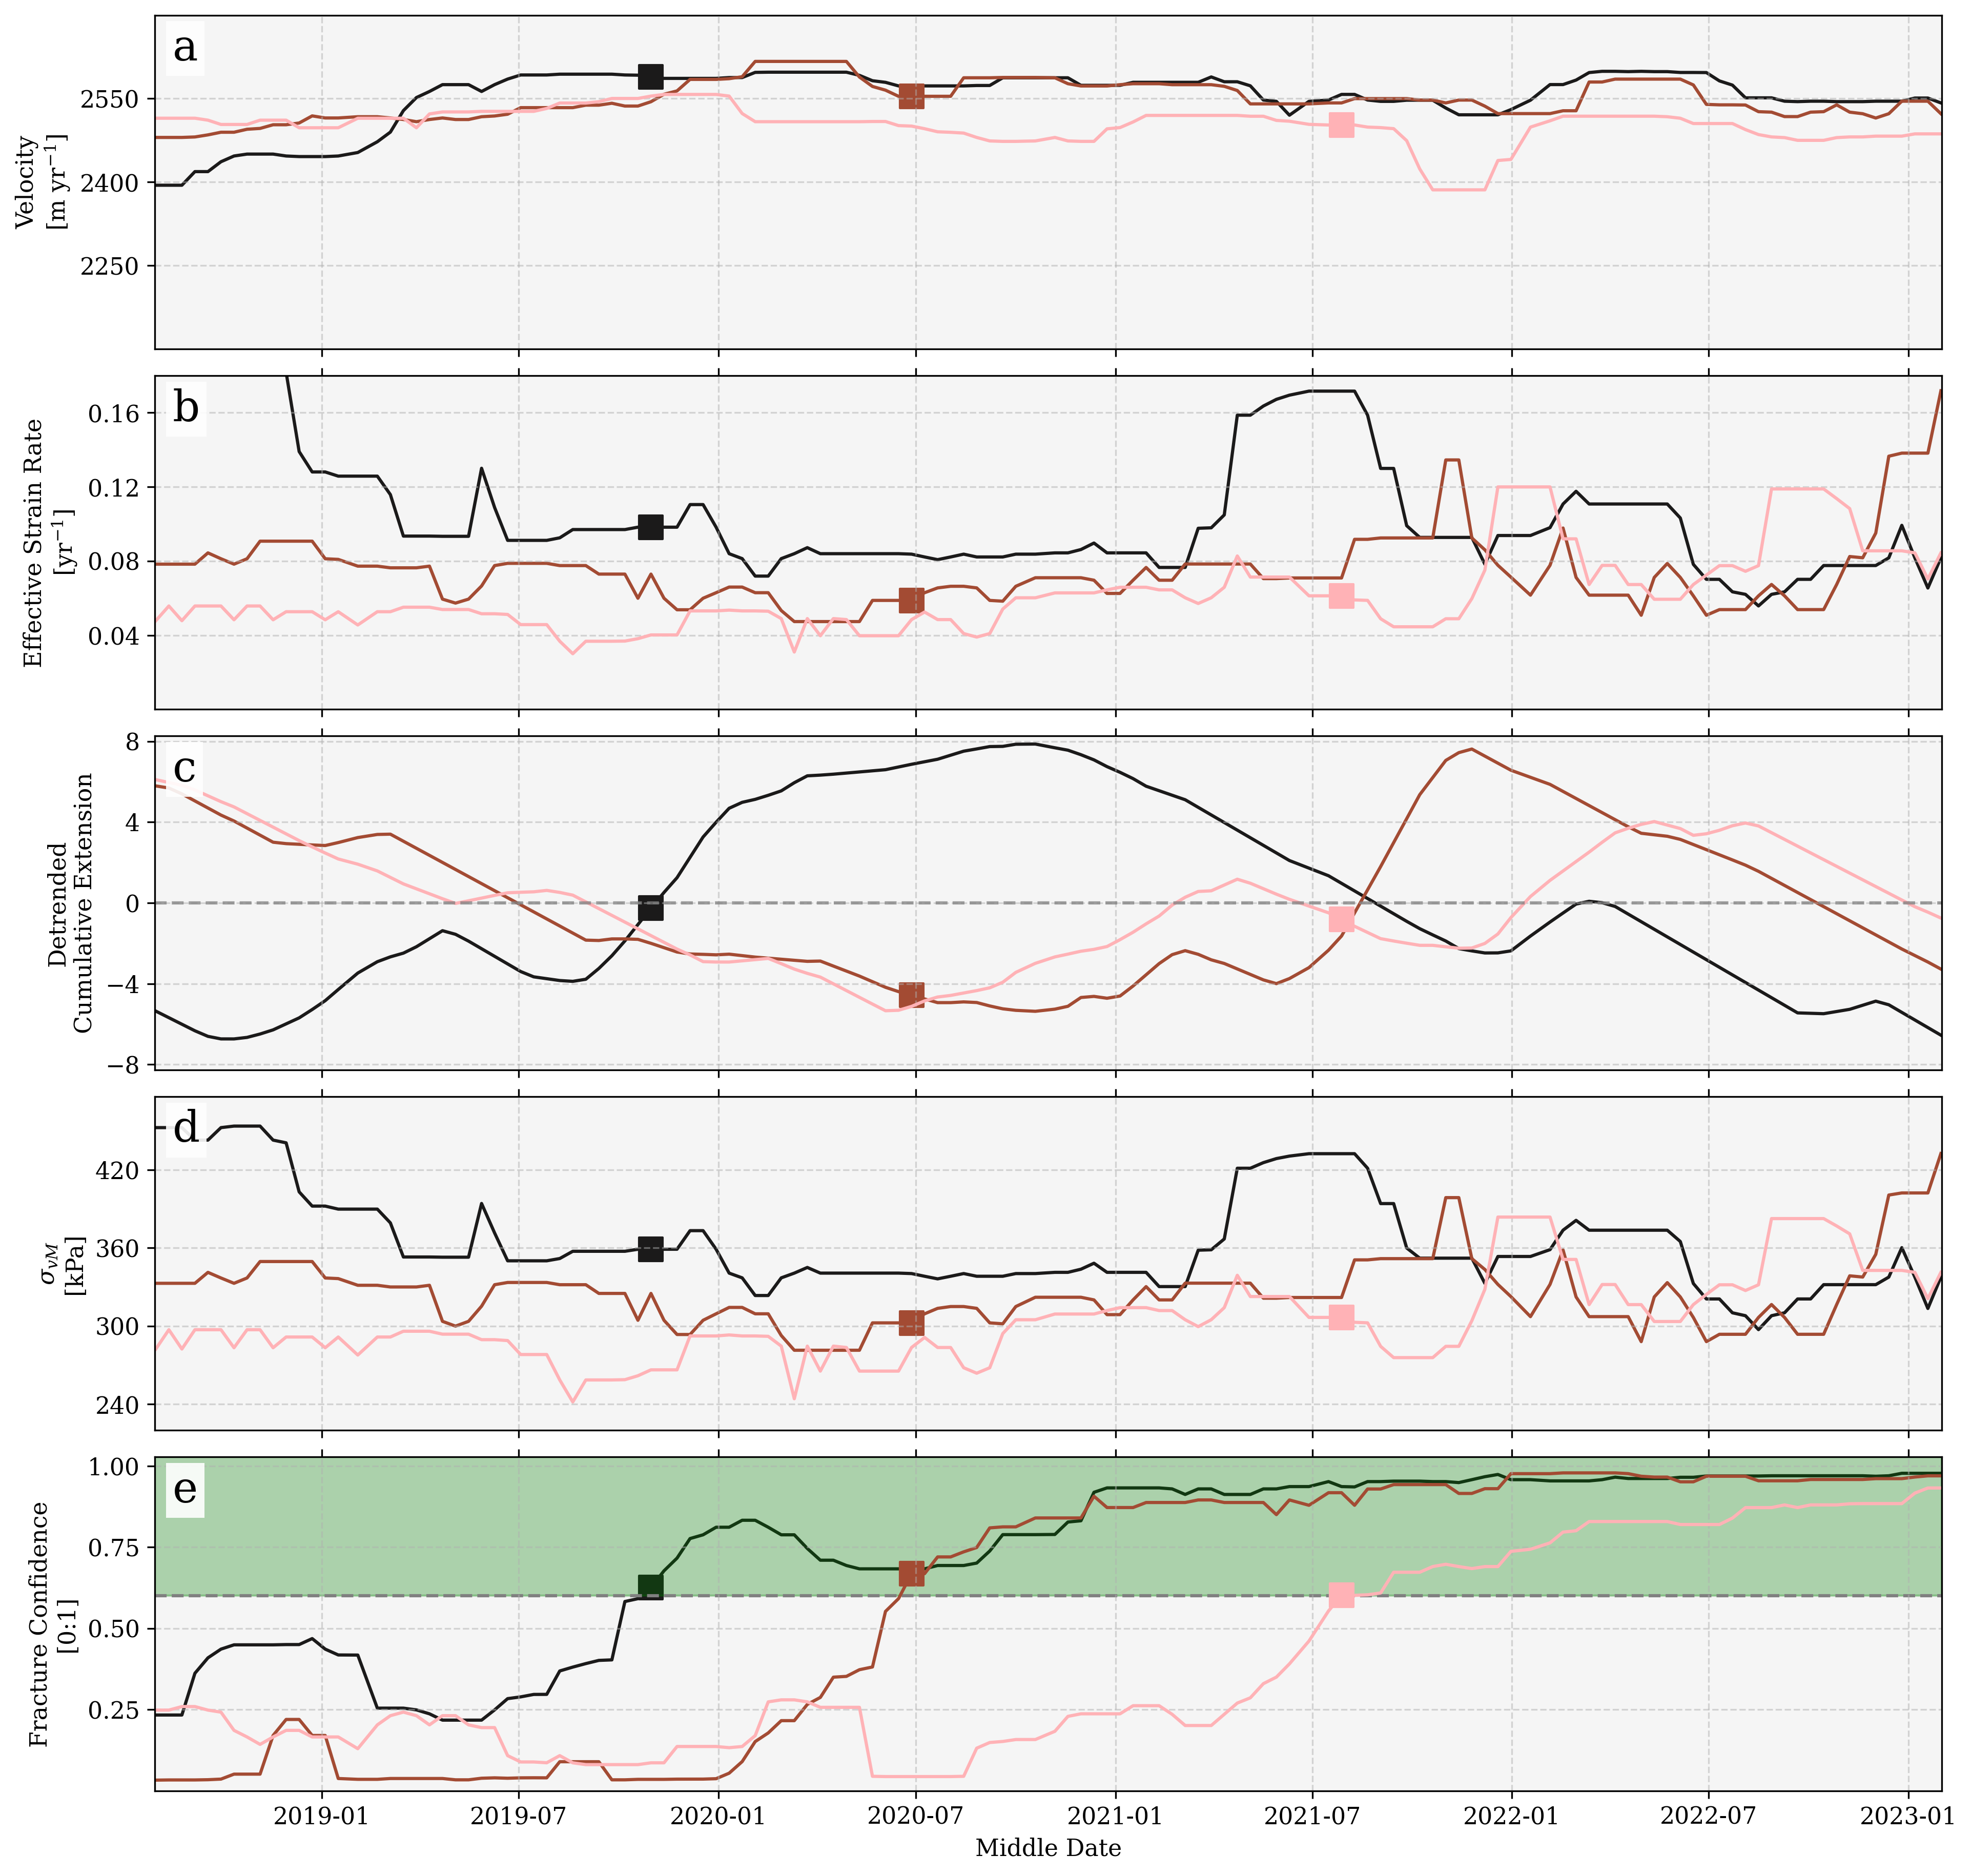

In [8]:
# . . Calculate cumulative detrended extension
eps_volumetric = parcels_singlecrev['eps_xx'] + parcels_singlecrev['eps_yy']
extension_rate = eps_volumetric.where(eps_volumetric > 0, 0)
time_days = (parcels_singlecrev['mid_date'] - parcels_singlecrev['mid_date'][0]) / np.timedelta64(1, 'D')
parcels_singlecrev['cumulative_extension'] = (extension_rate * np.gradient(time_days)).cumsum(dim='t')
parcels_singlecrev['detrended_ext'] = xr.apply_ufunc(
    lambda x: signal.detrend(x, type='linear'),
    parcels_singlecrev['cumulative_extension'],
    input_core_dims=[['t']],
    output_core_dims=[['t']],
    vectorize=True
)

# . . Panel definitions: (var, ylim, ylabel, extras)
panels = [
    ('vv',            (2100, 2700), 'Velocity\n[m yr$^{-1}$]',            {}),
    ('effective',     (0, 0.18),    'Effective Strain Rate\n[yr$^{-1}$]', {}),
    ('detrended_ext', (None, None), 'Detrended\nCumulative Extension',    {'hline': 0}),
    ('von_mises',     (220, None),  '$\\sigma_{vM}$\n[kPa]',              {}),
    ('fracture_conf', (0, None),    'Fracture Confidence\n[0:1]',         {'threshold': frac_thresh}),
]

plt.rcParams.update({"font.size": 11})

fig, axs = plt.subplots(len(panels), 1, figsize=(15, 15), sharex=False, dpi=300)
fig.subplots_adjust(hspace=0.08)

xmin, xmax = np.array(['2018-07-31', '2023-02-01'], 'datetime64')

for i, (ax, letter, (var, ylim, ylabel, extras)) in enumerate(zip(axs, 'abcde', panels)):
    parcel_lineplot(ax, parcels_singlecrev, var, ccm.amp_i)

    # . . Per-panel extras
    if 'hline' in extras:
        ax.axhline(extras['hline'], c='grey', ls='--', alpha=0.75)
    if 'threshold' in extras:
        ax.fill_between(
            [xmin, xmax], ax.get_ylim()[1], extras['threshold'],
            color='green', alpha=0.3, zorder=0
        )
        ax.axhline(extras['threshold'], color='grey', ls='--', zorder=0)

    # . . Formatting
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(None)
    ax.set_title(None)
    ax.grid(ls='--', alpha=0.5, zorder=0)
    ax.set_facecolor('whitesmoke')
    ax.tick_params(top=True, bottom=True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
    bit.plot_patch(ax, letter, fs=20, y=0.9)

    if i < len(axs) - 1:
        ax.set_xticklabels([])

axs[ 0].xaxis.set_ticks_position('bottom')
axs[-1].set_xlabel('Middle Date', fontsize=11)

plt.savefig('../media/f06-ex1-six-panel-timeseries.png', bbox_inches='tight')
plt.show()

## Repeat With Random Parcels

In [9]:
# . . Pick 6 unrelated parcels
x0 = np.array([
    1.36715e6,
    1.36680e6, 
    1.36970e6, 
    1.36850e6, 
    1.37075e6,
    1.37190e6, 
])
y0 = np.array([
    1.71880e6, 
    1.71600e6,  
    1.71950e6, 
    1.71400e6,  
    1.71650e6, 
    1.71185e6,
])
t0 = np.array(['2022-03-25']*len(x0))

# . . Advect Parcels
parcels_raw = tracker.parcel_advection(x0, y0, t0)
parcels_unrelated = bit.apply_med_filt(parcels_raw, size=(1, 10))  # Filter along time dimension

parcels_unrelated.to_netcdf('../data/trajectories/ex2-unrelated-parcels.nc')

### Figure 7: Random Parcels

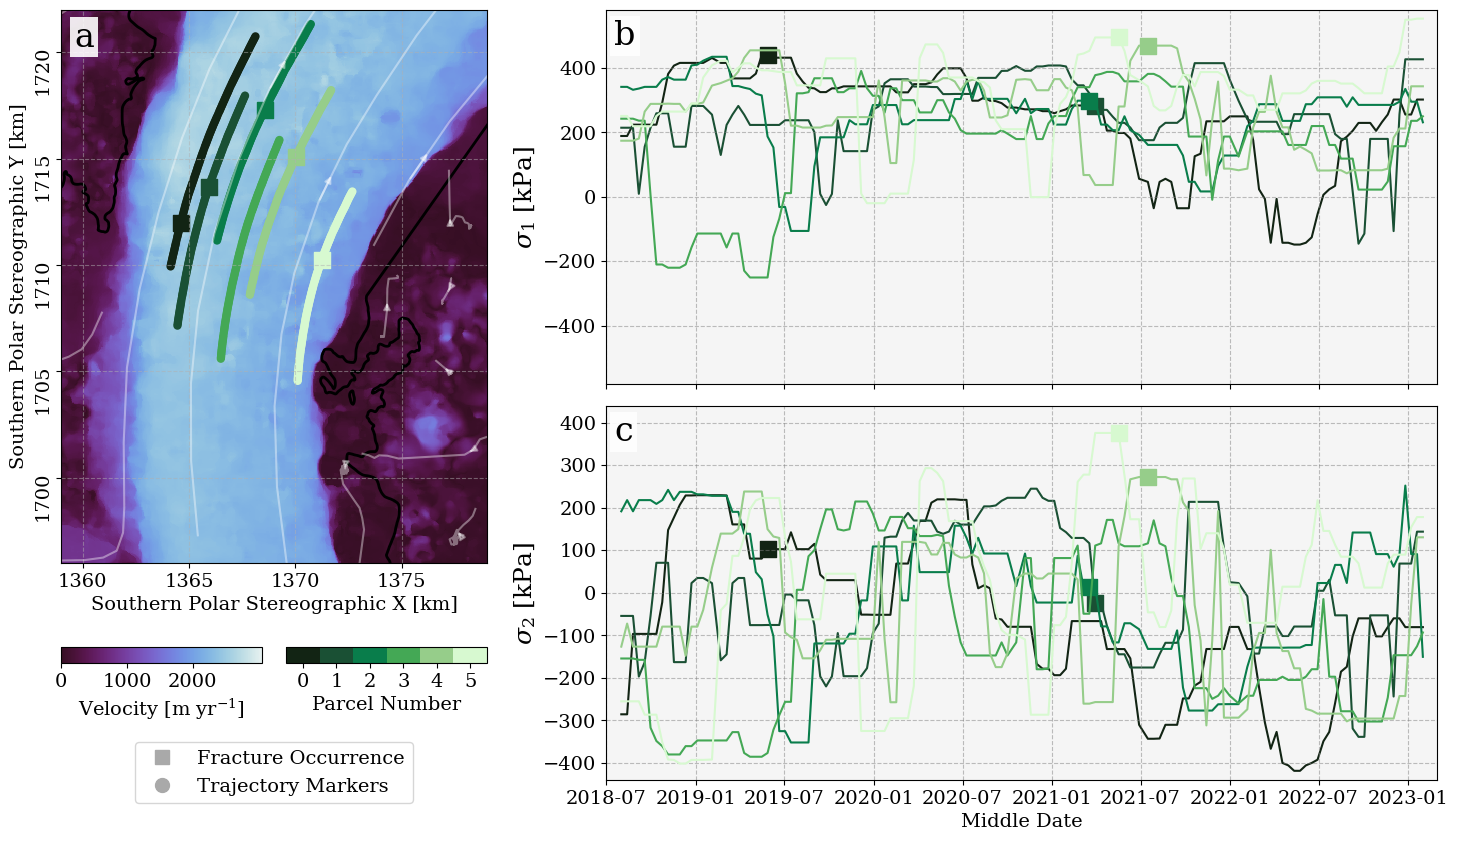

In [10]:
plt.rcParams.update({"font.size": 14})
plot_parcel_stresses(
    parcels_unrelated,  stress, shirase_shape, ccm.algae_r, 
    '../media/f07-ex2-map-principal-stresses.png'
)

### Figure 8: Principal stresses centered on fracture date

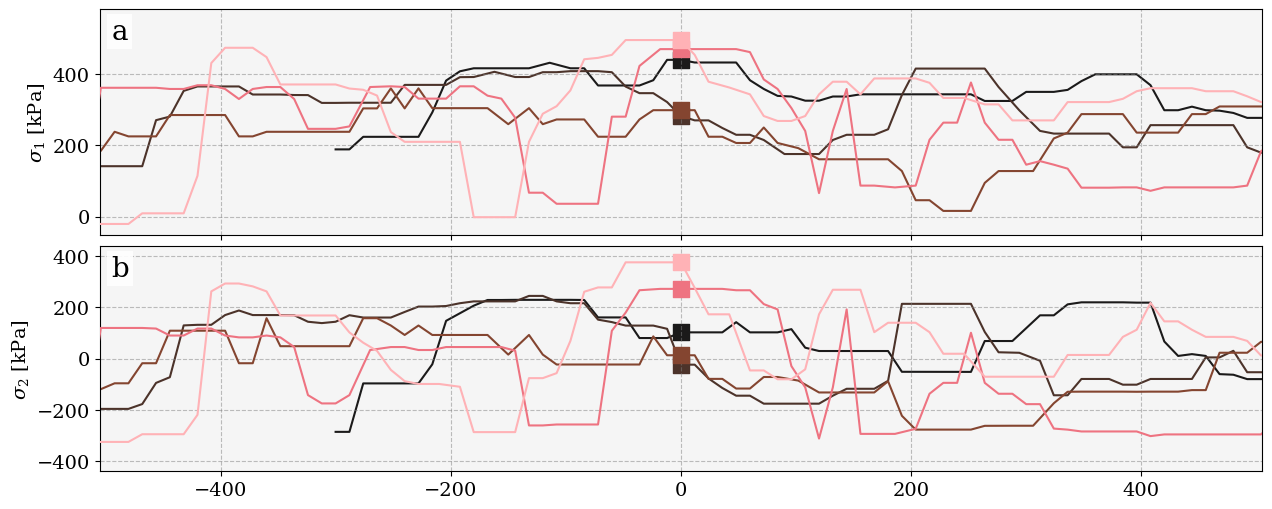

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(15, 6))
fig.subplots_adjust(hspace=0.05)

var_names = ['sigma1', 'sigma2']
ylabels = ['$\\sigma_1$ [kPa]', '$\\sigma_2$ [kPa]']
letters = list('ab')
for i, ax in enumerate(axs):
    parcel_lineplot(ax, parcels_unrelated, var_names[i], cmap, align='fracture')
    bit.plot_patch(ax, letters[i], fs=20, y=0.9)
    ax.set_facecolor('whitesmoke')
    ax.grid(ls='--', c='grey', alpha=0.5)
    ax.set_xlim(-505, 505)
    ax.set_ylabel(ylabels[i])

    if i < len(axs)-1:
        ax.set_xlabel(None)
        ax.set_xticklabels([])

axs[0].set_ylim(-50)

plt.savefig('../media/f08-ex2-principal-stresses-timedeltas.png', dpi=300, bbox_inches='tight')
plt.show()

## Parcel Ensemble

Pick an ensemble of random parcels from the ice shelf and advect them.
Using a large number, taking the mean, and establishing a confidence interval will allow us to see the broader behaviors of the ice shelf.

### Functions

In [12]:
########### Parcel Utilities #######################################
def get_valid_parcels(parcels, **kwargs):
    """Return an array of valid parcel ids (pids) and first fracture dates (fds) 
    for all parcels passing `check_valid_parcel` in an ensemble dataset.

    Parameters:
    -----------
    parcels : xr.Dataset
        Xarray dataset of parcels returned from LagrangianTracking. Must have 
        dimensions "parcel" and "mid_date" or "t"
    min_prev : int | float
        Minimum number of days before fracture to allow
    min_post : int | float
        Minimum number of days after fracture to allow

    Returns:
    --------
    (pids, fds) : tuple of lists
        Tuple parcel ids (list) and first fracture dates (list).
    """
    pids, fds = [], []
    for pid, group in parcels.groupby('parcel'):
        first_frac, valid = check_valid_parcel(group, **kwargs)
        if valid is None:
            continue
        pids.append(pid)
        fds.append(first_frac['mid_date'].values)
    return pids, fds


def check_valid_parcel(group, min_prev=200, min_post=200, thresh=0.6):
    first_frac = first_fracture(group, thresh=thresh)
    if first_frac is None:
        return None, None

    min_prev = np.timedelta64(min_prev, 'D')
    min_post = np.timedelta64(min_post, 'D')

    frac_date = first_frac['mid_date'].values
    days_before = frac_date - group['mid_date'].min().values
    days_after  = group['mid_date'].max().values - frac_date

    if days_before < min_prev or days_after < min_post:
        return None, None

    return first_frac, group

    
########### Ensemble Computation ###################################
def compute_ensemble_ci(parcels, pids, fds, bin_width=20, n_boot=1000, seed=None):
    """
    Return the bootstrapped Confidence Interval dataset aligned to fracture date
    for an ensemble of parcels.

    Parameters:
    -----------
    parcels : xr.Dataset
        Dataset consisting of parcels from LagrangianTracking. Must have dimensions
        (parcel, t).
    pids : list
        List of valid parcel ids
    fds : list
        List of first fracture dates
    bin_width : int | float
        Width to bin and average along the time axis in days. Defaults to 20.
    n_boot : int
        Number of iterations for bootstrapping operation. Defaults to 500.
    seed : int | None
        rng seed instance for reproducibility. Defaults to none.

    Returns:
    --------
    ci_ds : xr.Dataset
        dataset containing mean, high, and low confidence intervals for the
        parcels passed to the dataset.
    """
    rng = np.random.default_rng(seed)

    parcels_frac = parcels.sel(parcel=pids)
    delta = (parcels_frac['mid_date'].values[:, None] - fds) / np.timedelta64(1, 'D')
    parcels_frac['delta'] = (('parcel', 't'), delta.T)

    edges = np.arange(
        np.floor(float(delta.min()) / bin_width) * bin_width - bin_width / 2,
        np.ceil(float(delta.max()) / bin_width) * bin_width - bin_width / 2 + 1,
        bin_width
    )

    stacked = parcels_frac.stack(obs=('parcel', 't'))
    groups = stacked.groupby_bins('delta', bins=edges)

    ci = {var: {'lo': [], 'hi': [], 'mean': []} for var in parcels_frac.data_vars}
    centers = []

    for b, group in groups:
        parcel_means = group.groupby('parcel').mean('obs')
        centers.append(b.mid)
        for var in parcels_frac.data_vars:
            vals = parcel_means[var].values
            vals = vals[np.isfinite(vals)]
            if len(vals) < 10:
                ci[var]['lo'].append(np.nan)
                ci[var]['hi'].append(np.nan)
                ci[var]['mean'].append(np.nan)
                continue
            boot = [np.mean(rng.choice(vals, vals.size, replace=True)) for _ in range(n_boot)]
            lo, hi = np.percentile(boot, [2.5, 97.5])
            ci[var]['lo'].append(lo)
            ci[var]['hi'].append(hi)
            ci[var]['mean'].append(np.mean(vals))

    centers = np.array(centers)
    return xr.Dataset({
        var: xr.DataArray(
            np.array([ci[var]['mean'], ci[var]['lo'], ci[var]['hi']]).T,
            dims=['delta_bins', 'bound'],
            coords={'delta_bins': centers, 'bound': ['mean', 'lo', 'hi']}
        ) for var in parcels_frac.data_vars
    })
    

########### Plotting ###############################################
def plot_ensemble_ci(ax, ci_ds, var, color='red'):
    """Overlay bootstrapped mean and 95% CI band."""
    d = ci_ds.delta_bins.values
    line, = ax.plot(d, ci_ds.sel(bound='mean')[var].values, color=color, linewidth=1.5, zorder=3)
    fill = ax.fill_between(d,
                    ci_ds.sel(bound='lo')[var].values,
                    ci_ds.sel(bound='hi')[var].values,
                    color=color, alpha=0.3, zorder=2)
    return line, fill

def format_ensemble_ax(ax, letter, ylabel, xlim=(-500, 500)):
    ax.set_xlim(*xlim)
    ax.grid(ls='--', alpha=0.5, zorder=0)
    ax.axvline(0, ls=':', color='k', lw=1, zorder=1)
    ax.set_facecolor('whitesmoke')
    ax.set_ylabel(ylabel, fontsize=14)
    bit.plot_patch(ax, letter, fs=20, y=0.9)

### Parcel selection

In [13]:
# . . Create Ice Shelf Mask
gl_poly = gpd.GeoDataFrame(  # Convert line geometry to polygon for clipping
    geometry=list(polygonize(grounding_line.geometry)), crs=grounding_line.crs
)
clip_shapes = [
    {'gdf': gl_poly,       'invert': True, 'all_touched': True},  # Area outside grounding line
    {'gdf': shirase_shape, 'invert': False},                      # Area inside Shirase catchment
]

# . . Advect ensemble with set seed
N = 800   # Number of parcels
seed = 7  # RNG Seed
start = time()
parcel_ensemble = tracker.ensemble_advection(
    clip_shapes=clip_shapes,
    mask_date='2022-03-25',
    N=N,
    seed=seed
)
print(f"Runtime for {N} parcels: {time()-start:.0f} s")

parcel_ensemble.to_netcdf('../data/trajectories/ex3-ensemble-parcels.nc')

Runtime for 800 parcels: 1320 s


### Figure 9: Plot Ensemble Statistics

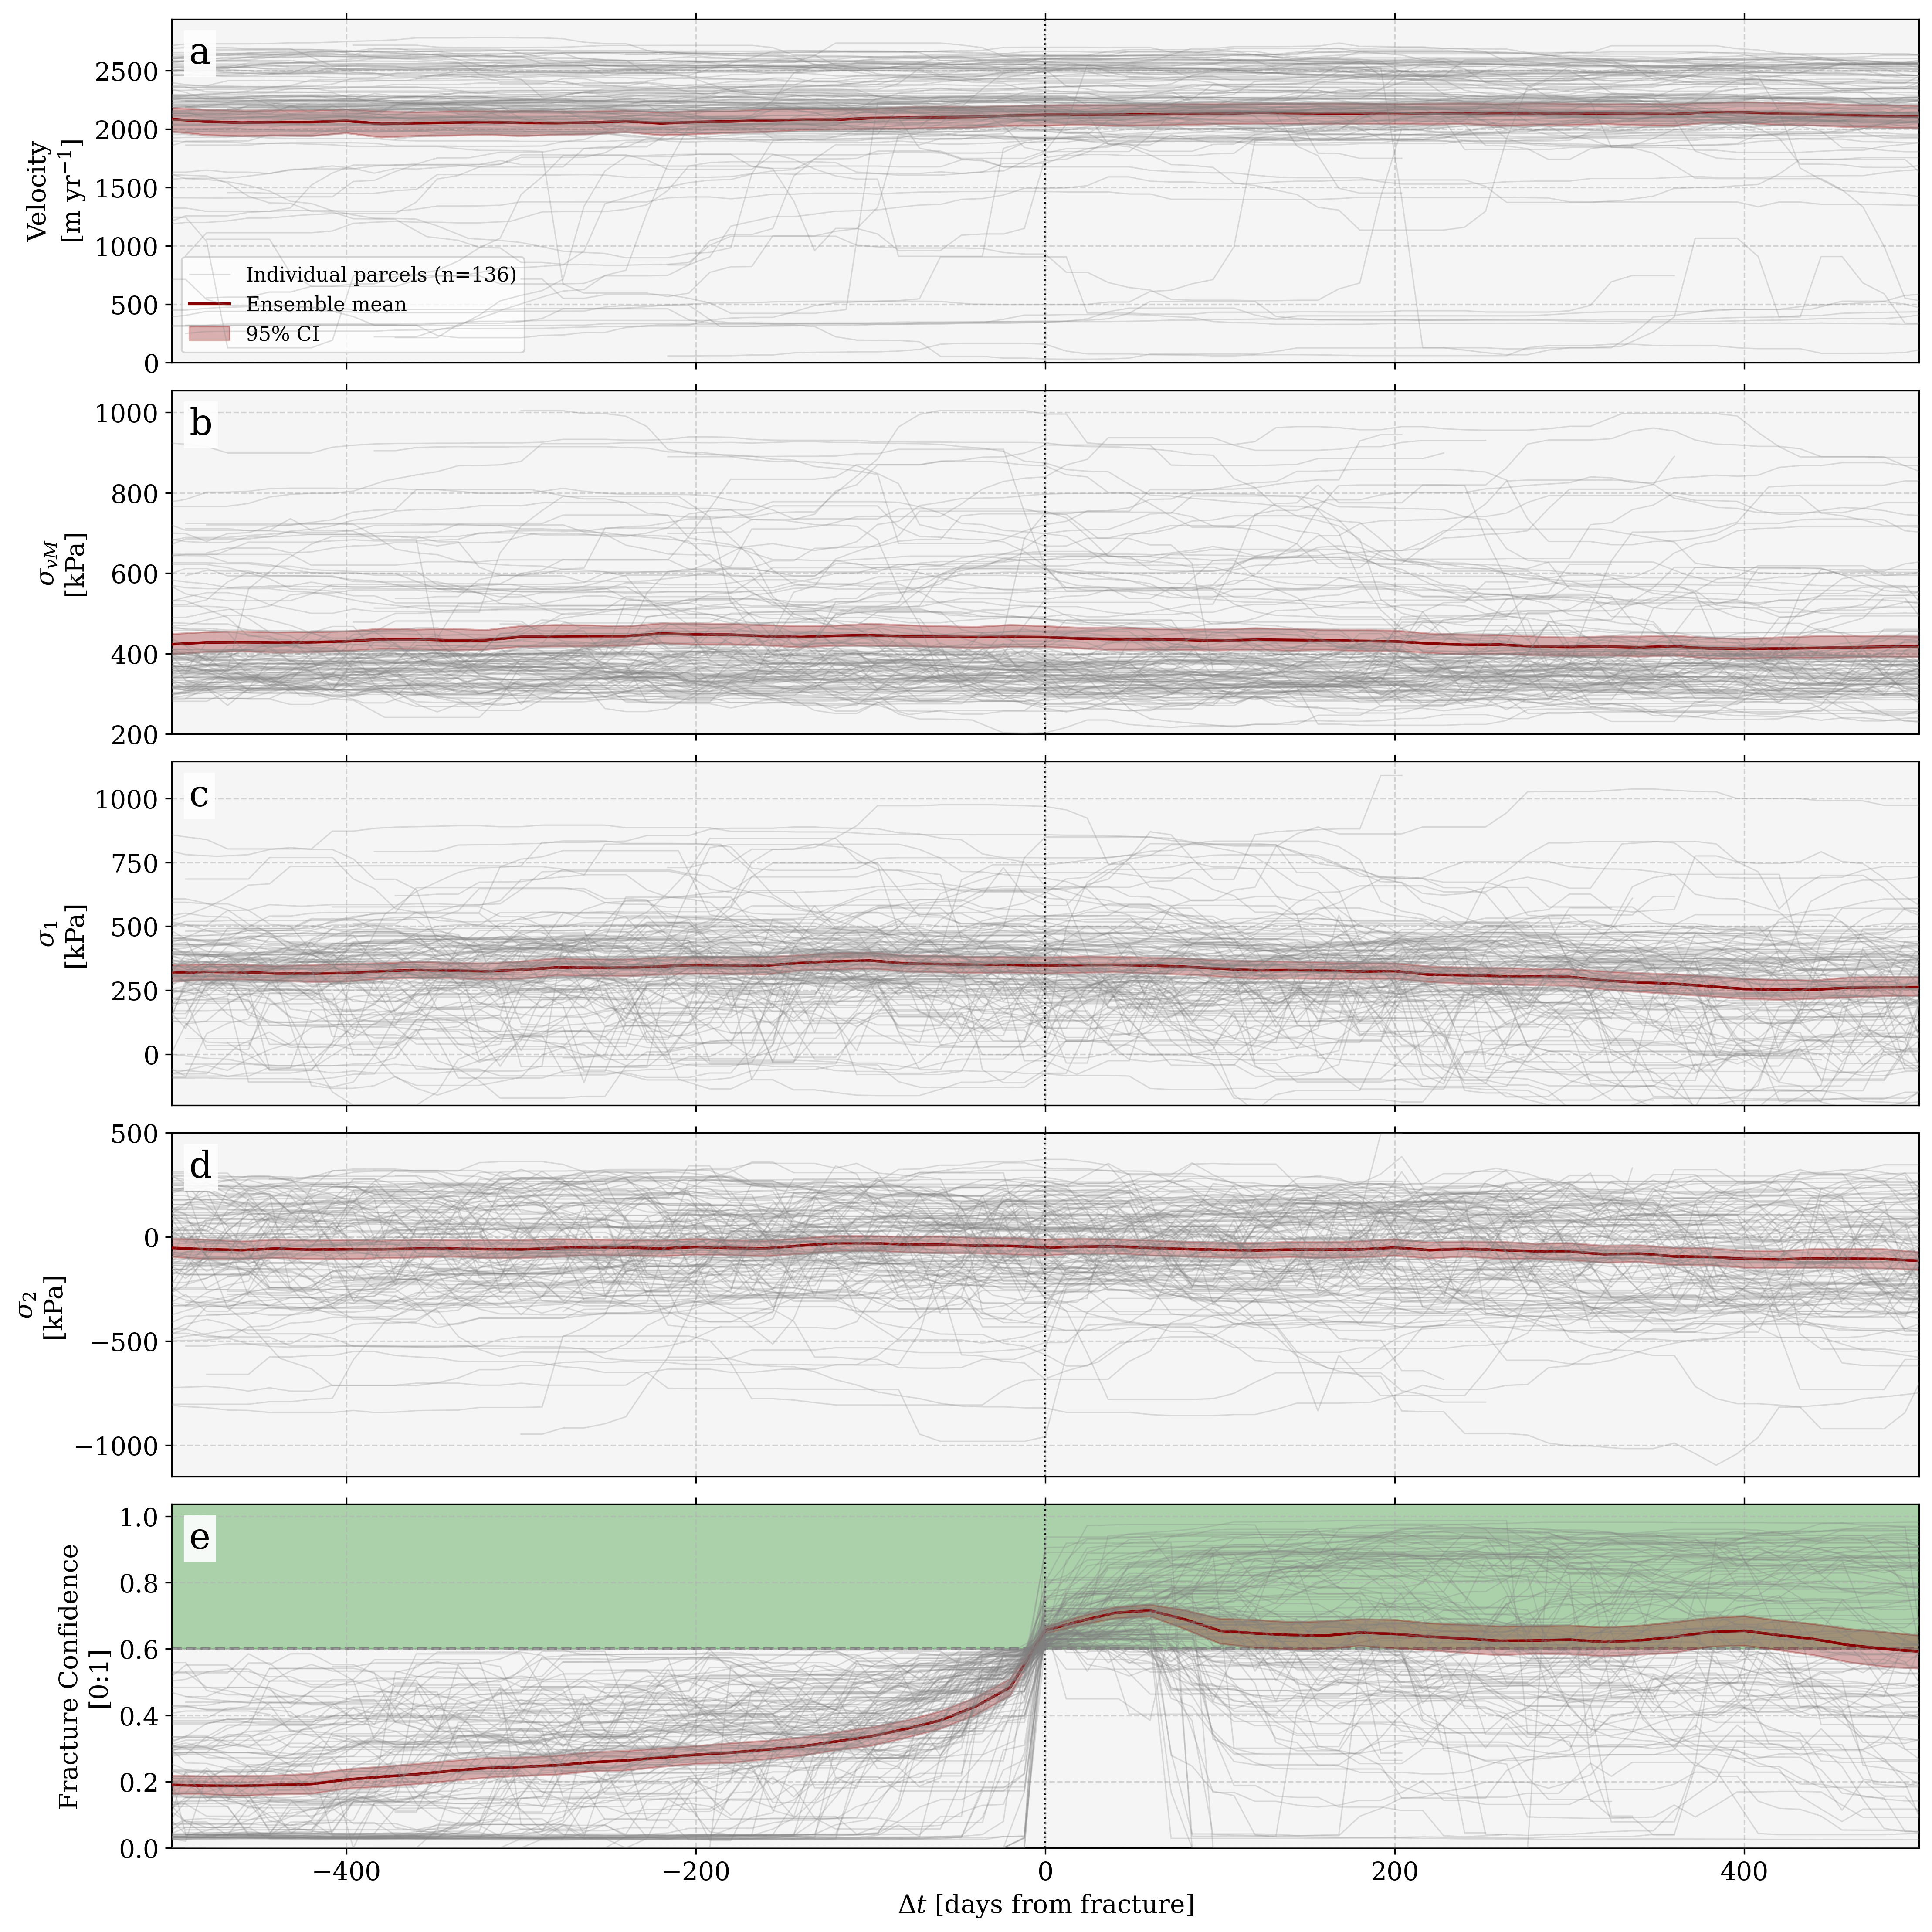

In [14]:
# . . Compute bootstrapped statistics on ensemble
pids, fds = get_valid_parcels(parcel_ensemble)
ci_ds = compute_ensemble_ci(
    parcel_ensemble, pids, fds, 
    bin_width=20, 
    seed=seed                    # Same seed as ensemble selection
)

# . . Select only valid parcels for plotting
valid_parcels = parcel_ensemble.sel(parcel=pids)

# . . List of panel details
panels = [  # (var name, (ymin, ymax), ylabel)
    ('vv',            (   0, None), 'Velocity\n[m yr$^{-1}$]'),
    ('von_mises',     ( 200, None), '$\\sigma_{vM}$\n[kPa]'),
    ('sigma1',        (-200, None), '$\\sigma_1$\n[kPa]'),
    ('sigma2',        (None,  500), '$\\sigma_2$\n[kPa]'),
    ('fracture_conf', (   0, None), 'Fracture Confidence\n[0:1]'),
]

fig, axs = plt.subplots(len(panels), 1, sharex=True, figsize=(15, 15), dpi=300)

for i, (ax, letter, (var, ylim, ylabel)) in enumerate(zip(axs, 'abcde', panels)):
    # Plot variable with CI
    parcel_line = parcel_lineplot(ax, valid_parcels, var, cmap, align='fracture', style='ensemble')
    mean_line, ci_fill = plot_ensemble_ci(ax, ci_ds, var, color='darkred')
    
    # prettify plots 
    format_ensemble_ax(ax, letter, ylabel)
    ax.set_ylim(*ylim)
    ax.tick_params(
        top=True, bottom=True
    )

    # . . Legend only on first axis
    if i == 0:
        ax.legend(
            [parcel_line, mean_line, ci_fill],
            [f'Individual parcels (n={len(pids)})', 'Ensemble mean', '95% CI'],
            loc='lower left', fontsize=11, framealpha=0.8
        )

# Fracture threshold band on bottom panel
axs[-1].fill_between(axs[-1].get_xlim(), axs[-1].get_ylim()[1], 0.6,
                     color='green', alpha=0.3, label='Above Threshold', zorder=0)
axs[-1].axhline(0.6, color='grey', linestyle='--', label='Threshold', zorder=0)
axs[-1].set_xlabel('$\\Delta t$ [days from fracture]', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(hspace=0.08)
fig.savefig('../media/f09-ex3-six-panel-timeseries.png', bbox_inches='tight')
plt.show()